# Text vs Image extraction comparison

Compares extracting invoice data two ways from the **same PDF**:

- **Path A (text)** -- `pdf_reader.py`'s 2D-layout-canvas text extraction, fed through the real production pipeline's two LLM passes (`llm_extract.extract_invoice_header` + `extract_line_items_chunked`), plus `apply_header_guardrails` (the same deterministic post-processing `reextraction.py` -- the actual production entry point every real run goes through -- applies). Not the full production loop: `reextraction.py`'s validation + retry step is intentionally left out here so both paths stay a fair single-shot comparison.
- **Path B (image)** -- the PDF's own page(s) rendered straight to an image and sent to the model, using the *same* extraction rules as Path A's prompts, the *same* model, and the *same* `reasoning_effort`/`verbosity` settings on the items pass, so any difference is attributable to the input modality, not the prompt content or the model's effort level.

Path B does **not** reuse `_HEADER_SYSTEM_PROMPT` / `_LINE_ITEMS_SYSTEM_PROMPT` verbatim, though -- those open by telling the model it receives "layout-preserved 2D spatial text" and that a "│" character marks column boundaries, which is actively misleading for an image (there's no such character, and describing a text canvas to a model looking at a picture invites it to hunt for something that will never appear). `_adapt_prompt_for_image()` (below, just before Path B's extraction calls) swaps only that opening preamble for an image-appropriate equivalent via an exact, asserted substring replace -- every substantive field-extraction rule after it is untouched and stays byte-identical to production, and stays in sync automatically if those rules change later.

This is intentionally **not** a perfectly controlled A/B (Path A gets production's text-only guardrails, Path B is a raw two-pass baseline with none) -- it's "what the real pipeline does today" vs "what a naive image-only pass would get", which is the comparison that's actually useful to look at.

## Suggested hard PDF

`6810995125_Commercial Invoice_1.pdf` (in `C:\Users\T106\Downloads\Set_1\Set_1`). This one's digital text layer is genuinely corrupted **at the source** -- confirmed earlier: the Sold-To and Ship-To address columns are interleaved in the PDF's own content stream, so even raw `pdfplumber` character extraction (before any of this project's own clean-up logic runs) already reads "INDIA" as "INDIPrivate", "MOULD PLOT" as "MOOWPLOT", etc. Since the corruption is baked into the text layer itself -- not something `pdf_reader.py`'s de-dupe logic can fix -- this is exactly the kind of file where sending the raw page *image* (bypassing text extraction entirely) has the best real chance of beating the text path. It's a genuinely digital (selectable-text) PDF, not a scan, so it's a fair test of text-vs-image rather than OCR-vs-image.

Swap `PDF_PATH` below for any other selectable-text PDF to compare instead.

In [9]:
import sys, os, io, json, time, base64
from pathlib import Path

sys.path.insert(0, str(Path.cwd()))  # this notebook lives in Pray/, project root

import pypdfium2 as pdfium
from openai import AsyncOpenAI

from pdf_reader import extract_text
from llm_extract import (
    extract_invoice_header,
    extract_line_items_chunked,
    apply_header_guardrails,
    _HEADER_SYSTEM_PROMPT,
    _LINE_ITEMS_SYSTEM_PROMPT,
    _is_reasoning_model,
    _extract_json,
    _extract_usage,
    _calculate_cost,
    _call_header_model,
    _call_line_items_model,
)
# extract_fields() (this notebook's original import) no longer exists --
# it was split into extract_invoice_header() + extract_line_items_chunked()
# (the header/items passes, run separately) plus apply_header_guardrails()
# (deterministic post-processing), which is what reextraction.py -- the
# actual production entry point every real pipeline run goes through --
# calls today. Path A below now mirrors that directly (minus reextraction's
# own validation/retry loop, kept out so both paths stay a fair single-shot
# comparison -- see cell 5).
#
# llm_extract.py already calls load_dotenv() on import, so OPENAI_API_KEY
# from a .env file in the project root is picked up automatically.

In [10]:
PDF_PATH = r"C:\Users\T106\Downloads\Set_1\Set_1\6810995125_Commercial Invoice_1.pdf"
MODEL = "gpt-5-nano"   # same model for both paths -- keeps the comparison to input modality only
IMAGE_DPI = 250          # render scale for the image path; raise if fine print gets lost

## Path A -- extracted text -> LLM

In [11]:
text, tables_text, method, ocr_time, scan_quality = extract_text(PDF_PATH)
print(f"extraction method: {method}  ({len(text)} chars, ocr_time={ocr_time}s)")
print(text[:3000])

extraction method: 2d_layout_canvas  (15571 chars, ocr_time=0.0s)
=================================== PAGE 1 OF 5 (6810995125_Commercial Invoice_1.pdf) ===================================
                (1)                                                           │                                                          Confidential
                                                                      Gold Circuit Electronics Ltd.
                                                              No.113, Shi Yuan Rd., Jhongli Dist. Taoyuan City
                                                                            32057 ,Taiwan
                                                                          TAX ID:30955404
                                              FAX#: (03) 250-6379                 │                TEL#: (03) 461-2541
                                                                              Invoice
                Invoice NO:     │    2464526
                SOLD 

In [12]:
t0 = time.perf_counter()
text_header, header_usage = await extract_invoice_header(text, model=MODEL, tables_text=tables_text)
text_items, items_usage = await extract_line_items_chunked(text, model=MODEL, tables_text=tables_text)
# Same deterministic post-processing production applies after the LLM
# calls (net_realisable_amount / invoice_total / total_packages fixes
# anchored back to the source text) -- mutates text_header in place.
# There's no equivalent for Path B: these guardrails work by re-checking
# the LLM's answer against the EXTRACTED TEXT, which the image path never
# has. That asymmetry is real and part of what's being compared, not a bug
# to paper over.
apply_header_guardrails(text_header, text_items, text)
text_elapsed = time.perf_counter() - t0

text_usage = _calculate_cost(
    MODEL,
    header_usage["input_tokens"] + items_usage["input_tokens"],
    header_usage["cached_tokens"] + items_usage["cached_tokens"],
    header_usage["output_tokens"] + items_usage["output_tokens"],
)

print(f"[TEXT PATH] {text_elapsed:.1f}s, {text_usage['total_tokens']} tokens, "
      f"${text_usage['cost_usd']:.5f} (INR {text_usage['cost_inr']:.4f})")
print(json.dumps(text_header, indent=2, ensure_ascii=False))
print(f"\n{len(text_items)} line item(s):")
print(json.dumps(text_items, indent=2, ensure_ascii=False))

[TEXT PATH] 58.0s, 24544 tokens, $0.00397 (INR 0.3374)
{
  "invoice_number": "2464526 / 2464527 / 2470788 / 2470789 / 2470790",
  "invoice_date": "2026-07-17 / 2026-07-18 / 2026-07-17 / 2026-07-17 / 2026-07-19",
  "supplier_name": "Gold Circuit Electronics Ltd.",
  "supplier_address": "No.113, Shi Yuan Rd., Jhongli Dist. Taoyuan City\n32057 ,Taiwan",
  "supplier_tax_id": "30955404",
  "buyer_name": "FLEXTRONICS INTERNATIONAL MANAGEMENT SERVICES LTD",
  "buyer_address": "LEVEL 3 ALEXANDER HOUSE 35 CYBERCITY EBENE\nMAURITIUS",
  "consignee_name": "FLEXTRONICS TECHNOLOGIES (INDIA) Private Limited",
  "consignee_address": "NO3 SIPCOT INDUSTRIAL PARSANDAVELLORE\nVillage, SUGUVAR 602106\nSRIPERUMBUDUR, INDIA",
  "currency": "USD",
  "invoice_total": "3720.0000 / 12000.0000 / 12400.0000 / 37200.0000 / 37200.0000",
  "net_realisable_amount": null,
  "tax_amount": null,
  "tax_rate": null,
  "payment_terms": "01.T/T 90 Days",
  "country_of_origin": "Taiwan",
  "country_of_destination": "INDIA",

## Path B -- raw page image -> LLM

5 page image(s) rendered


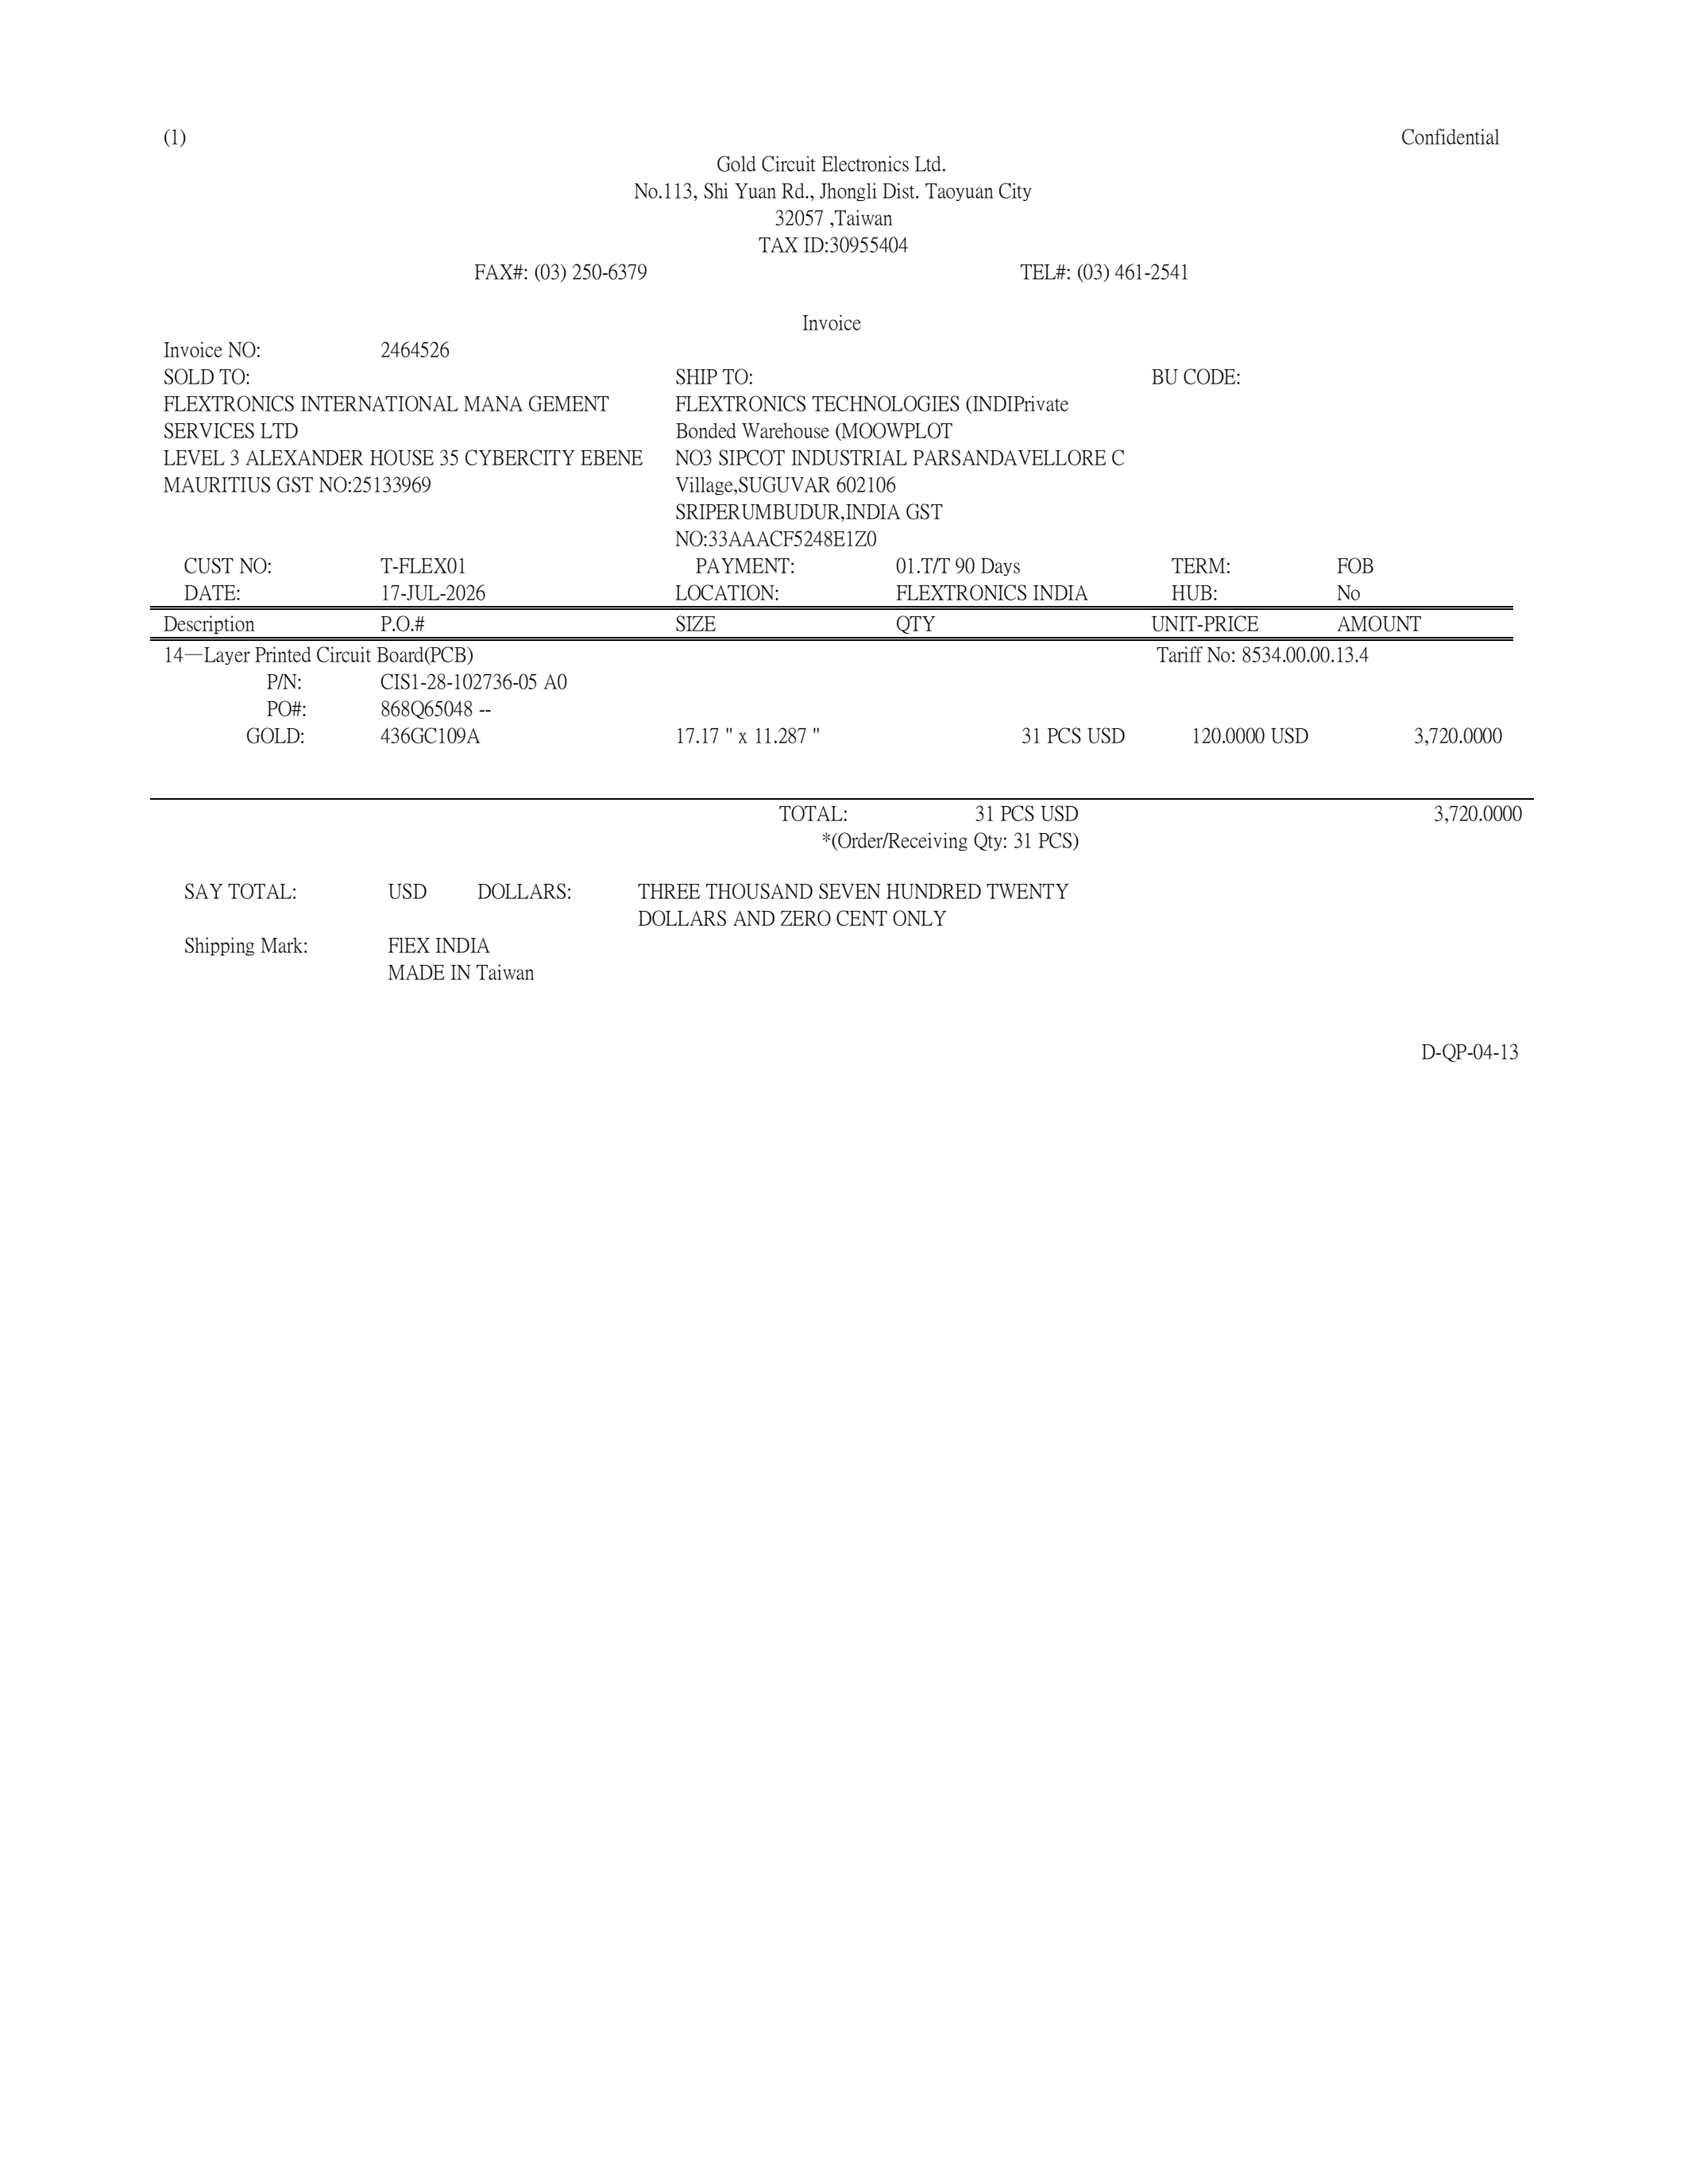

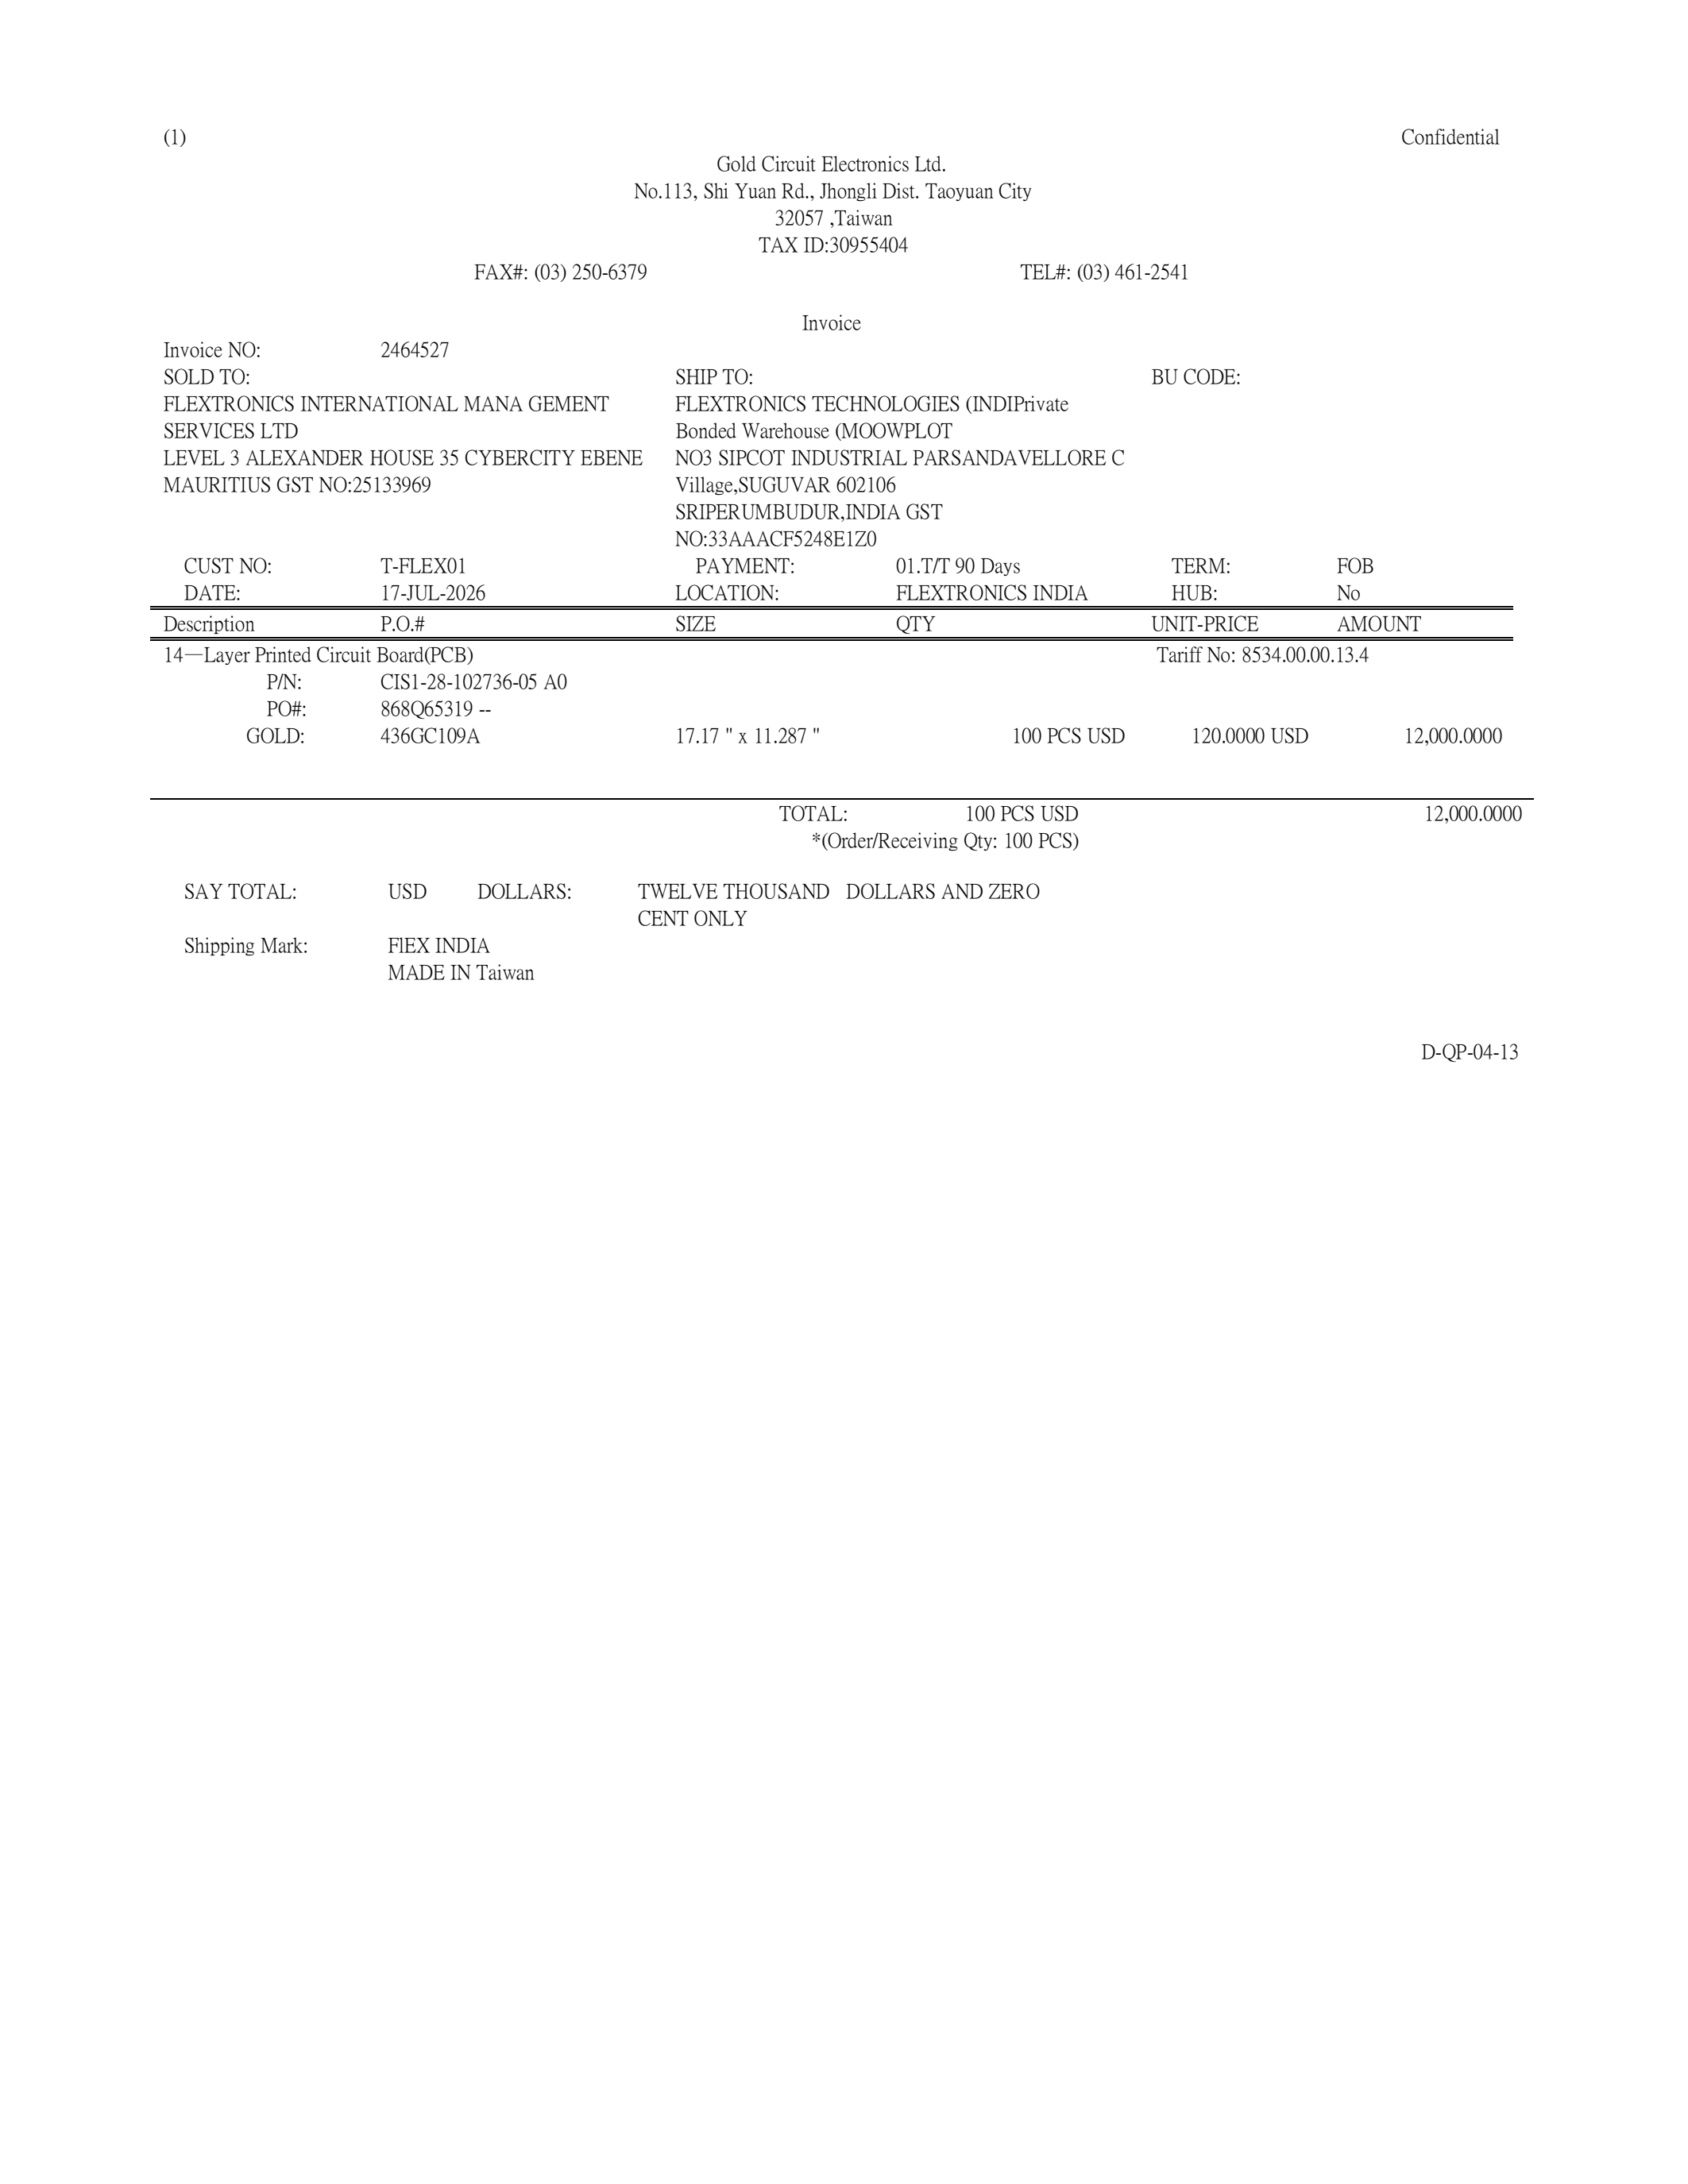

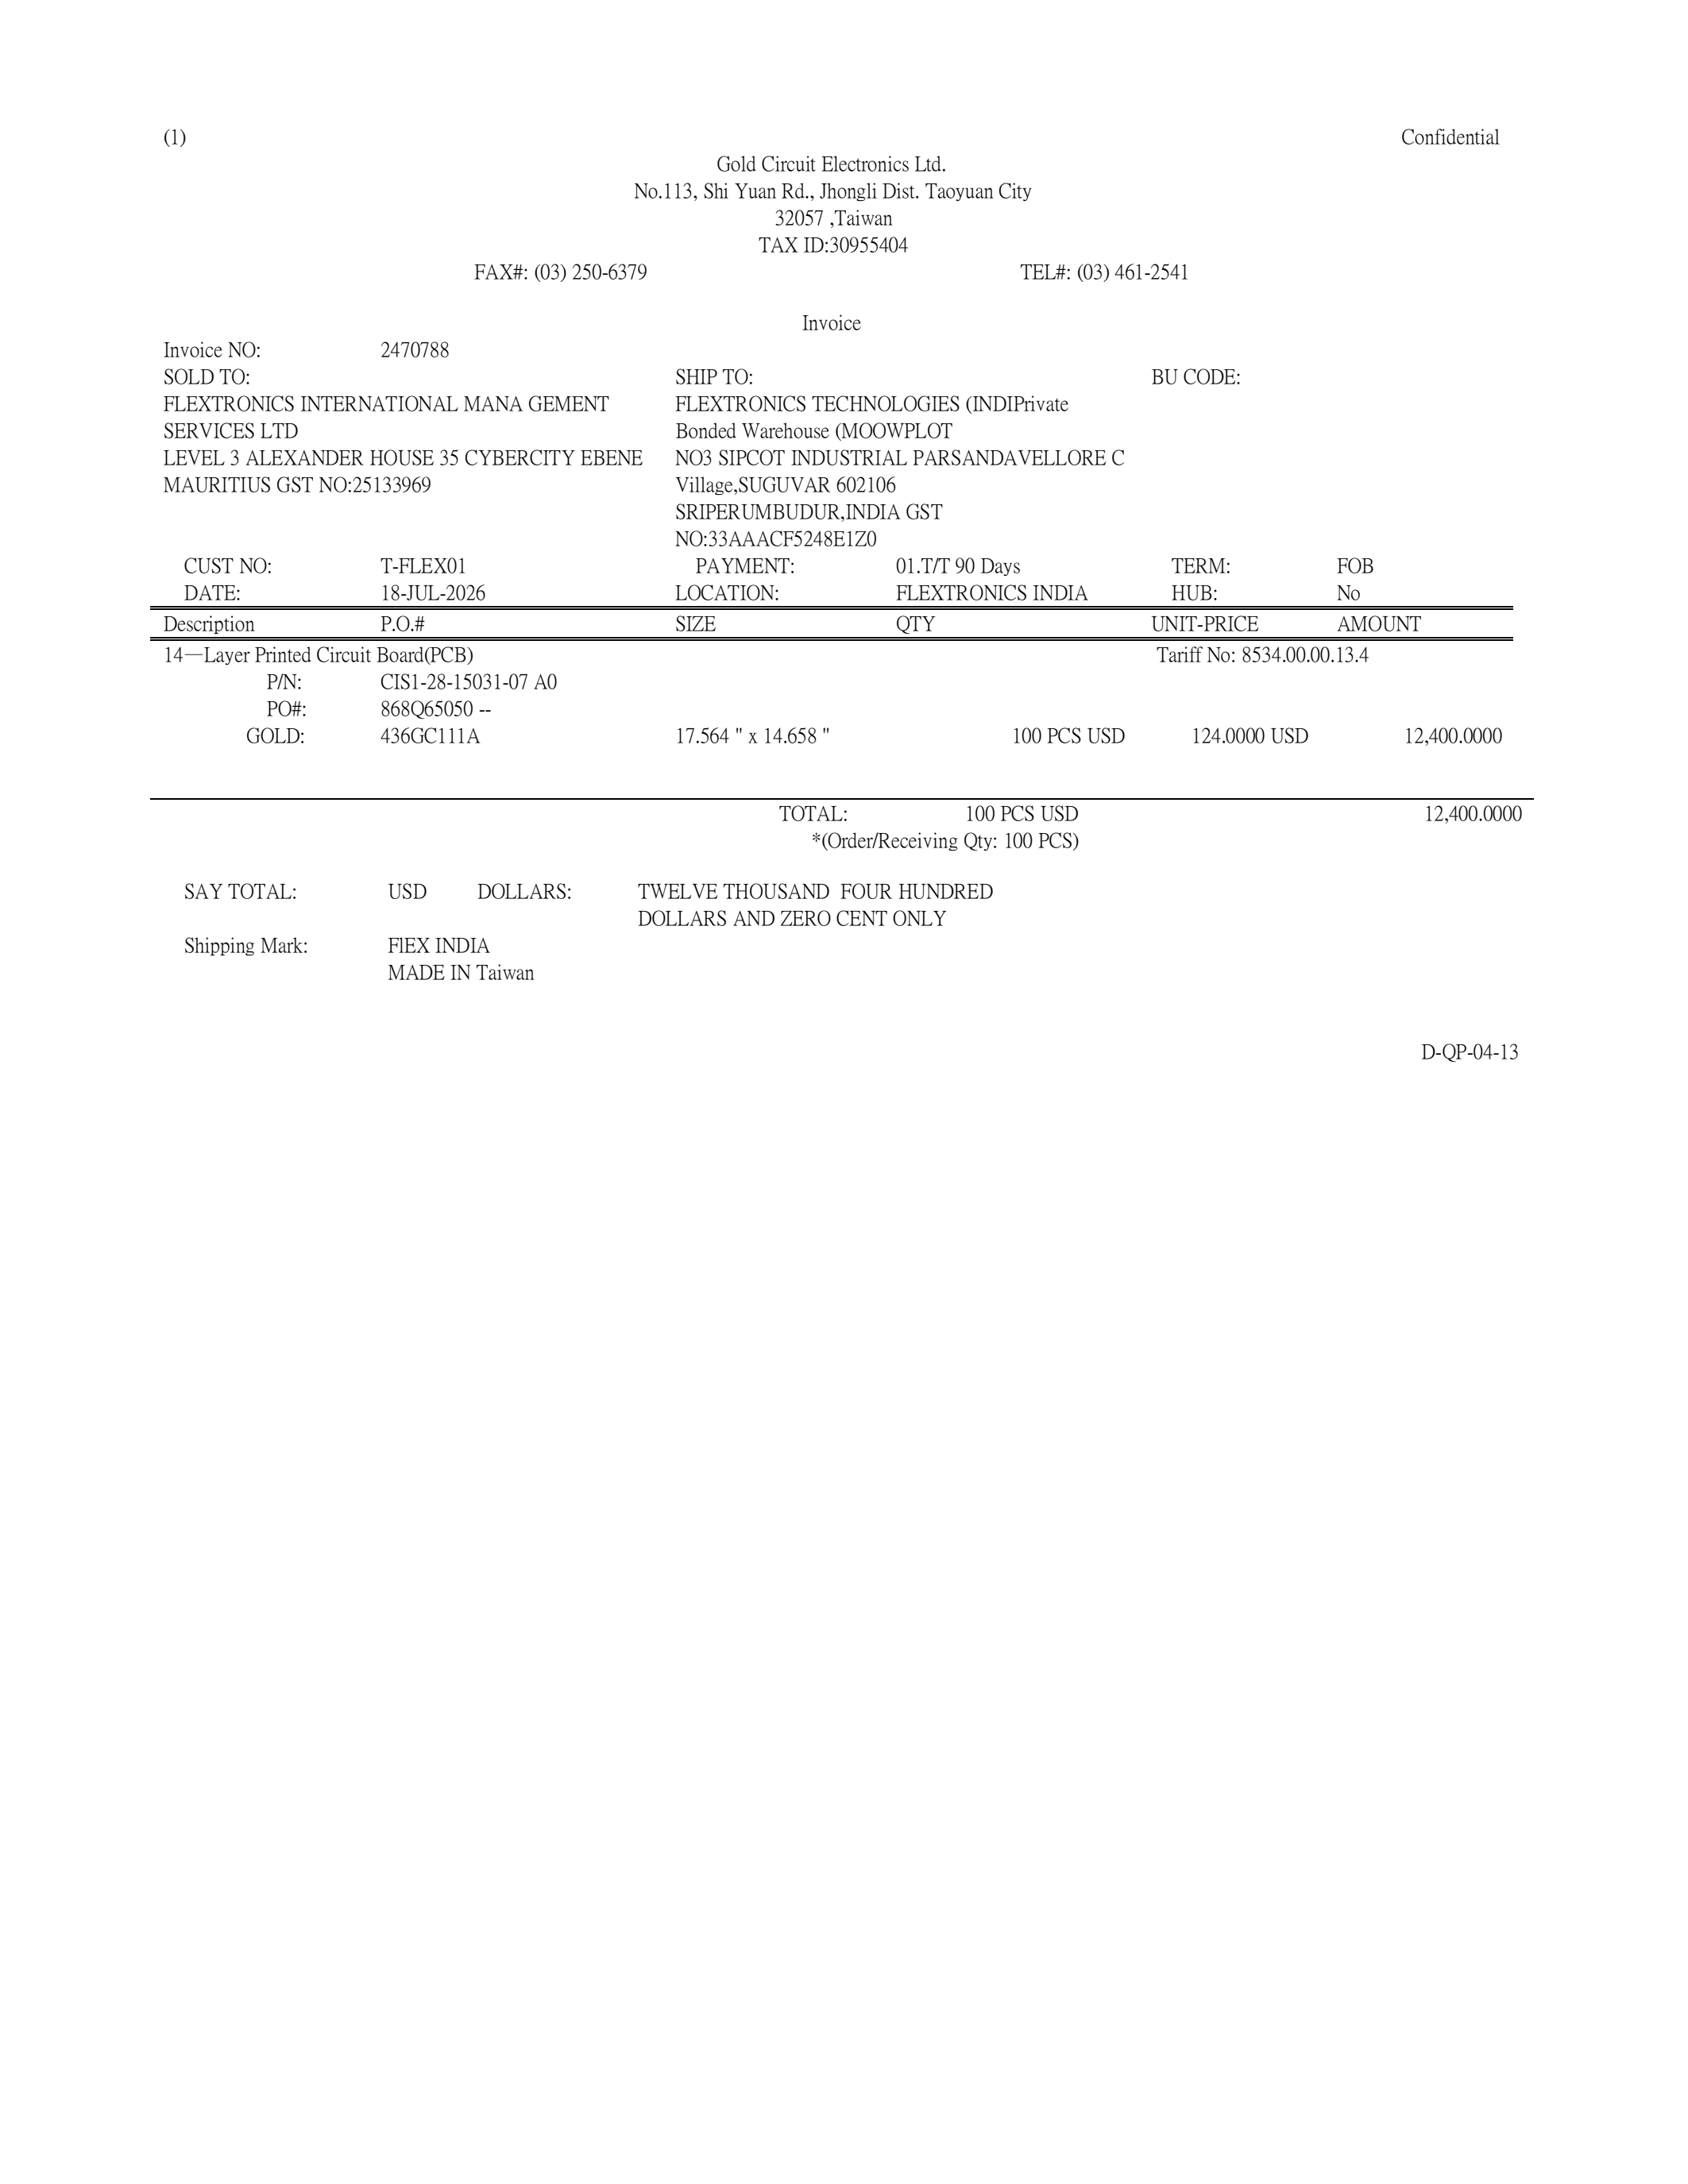

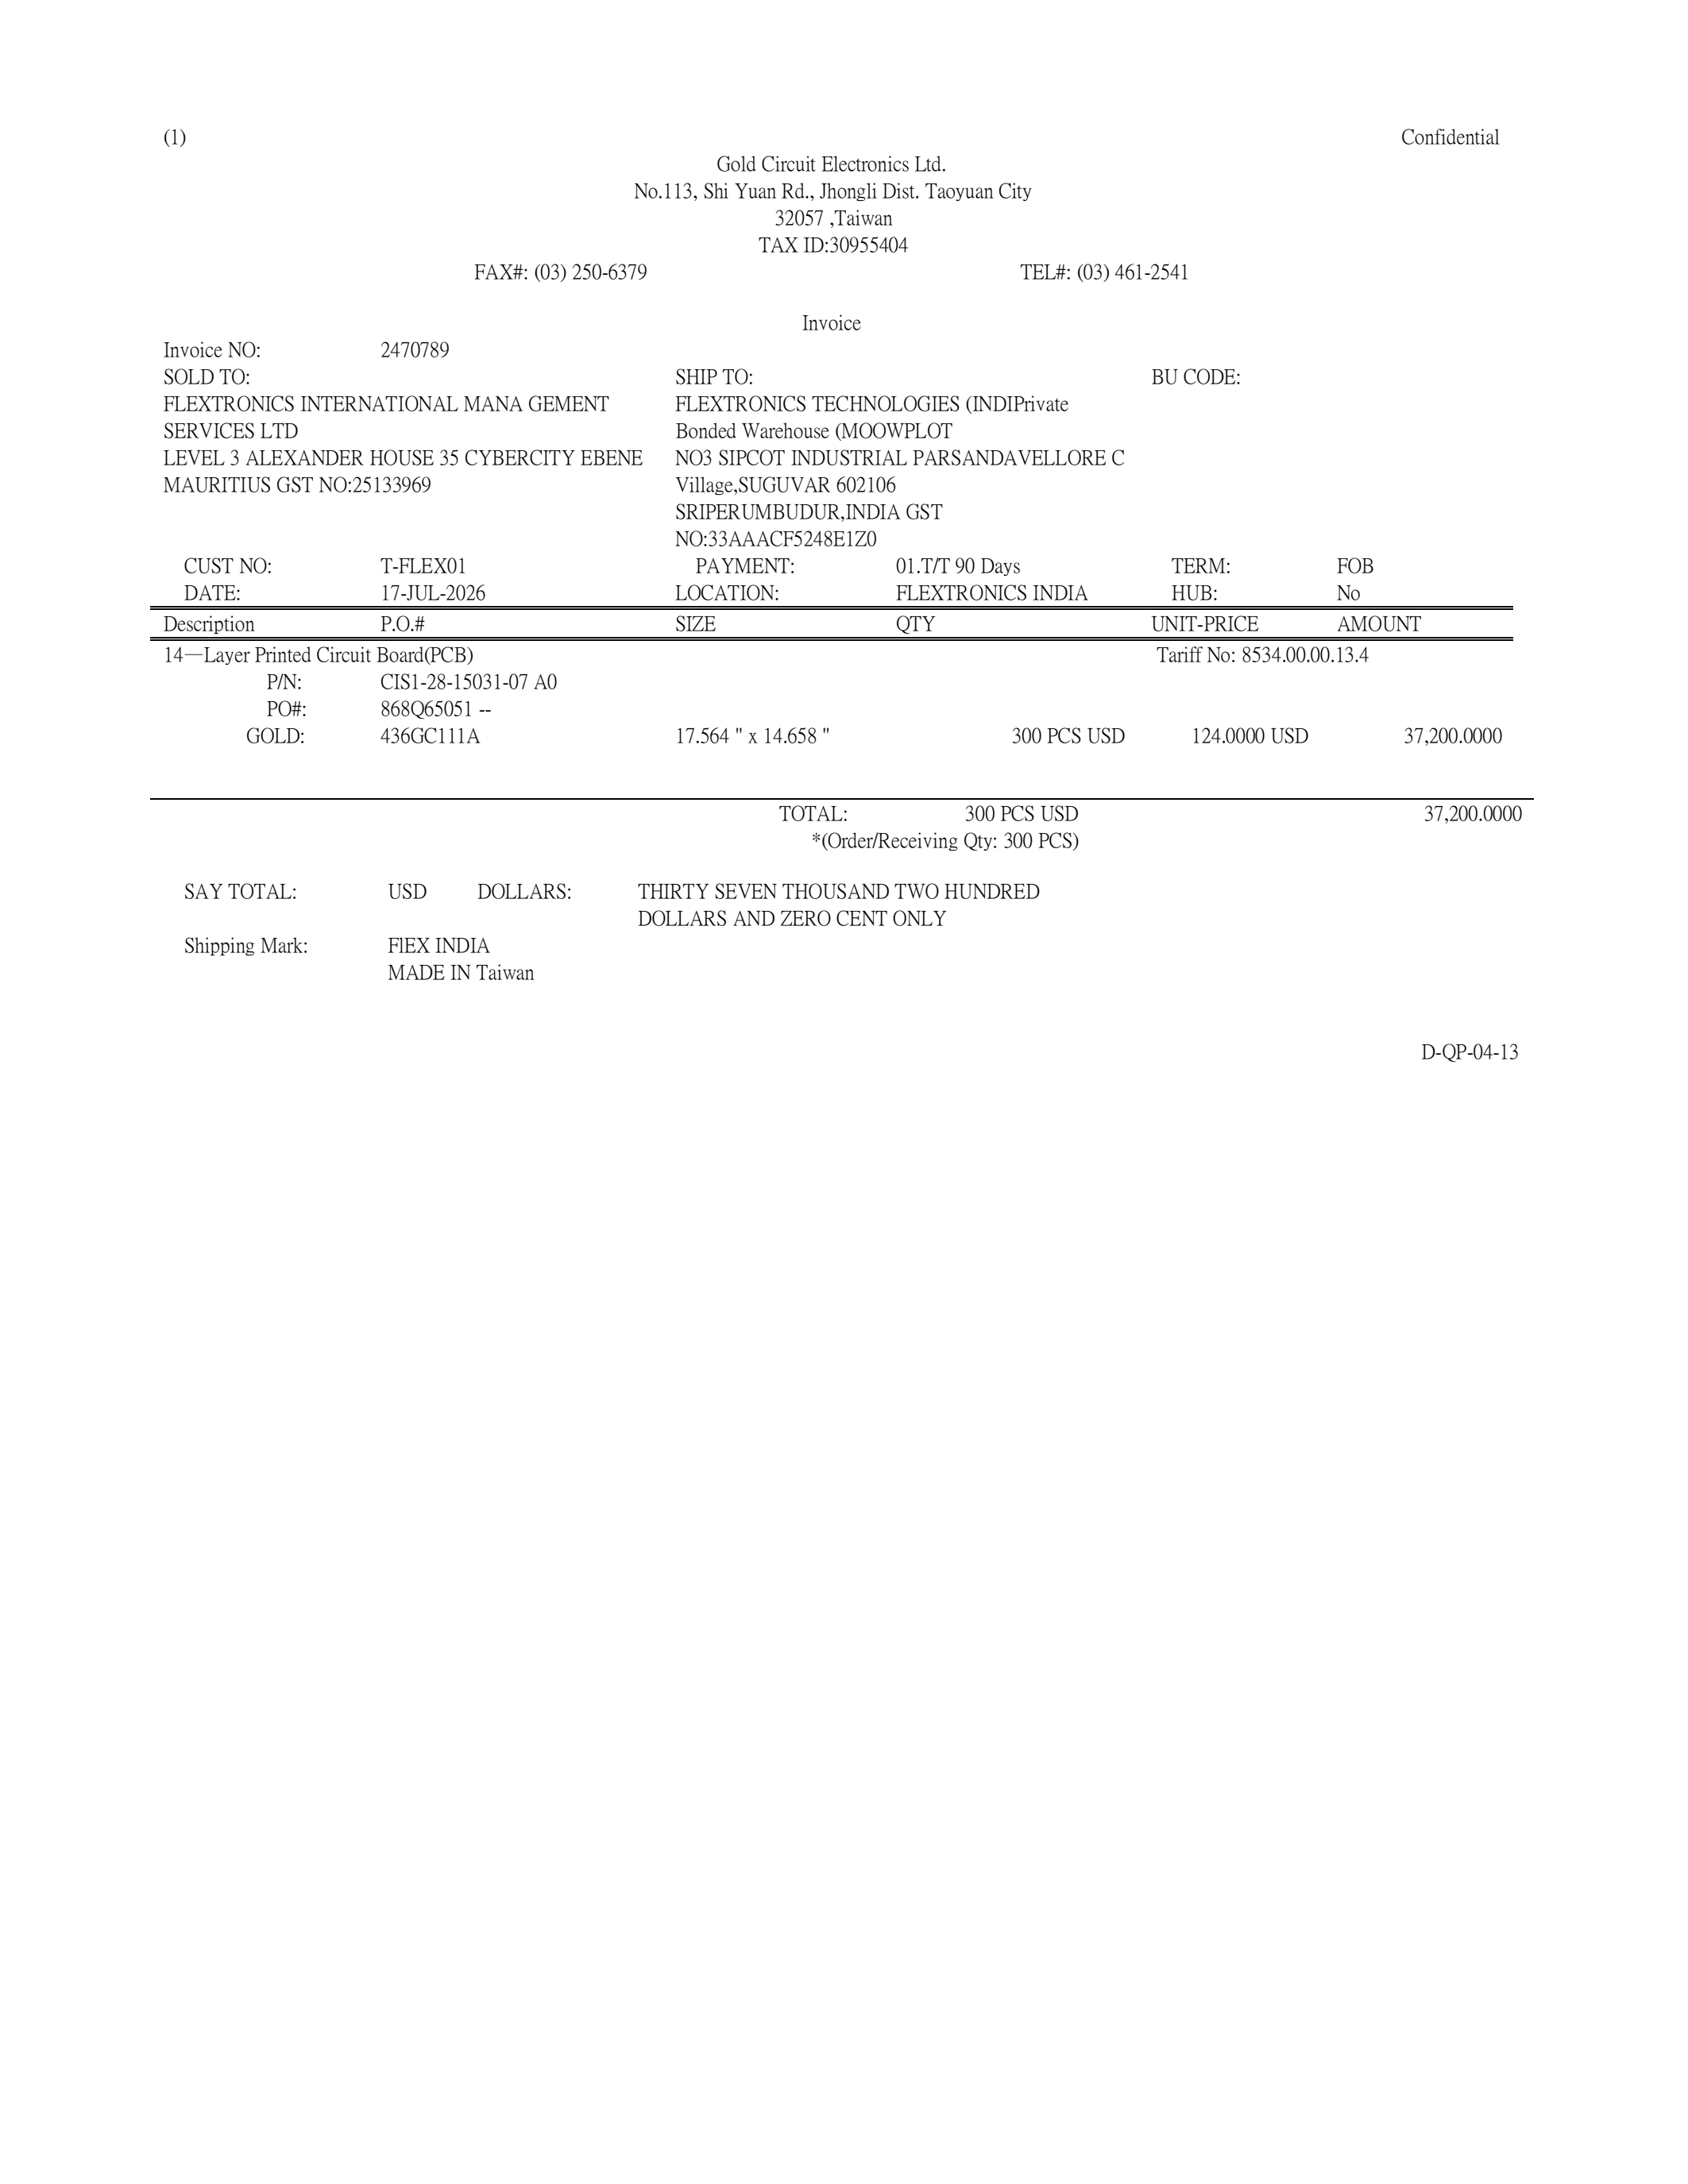

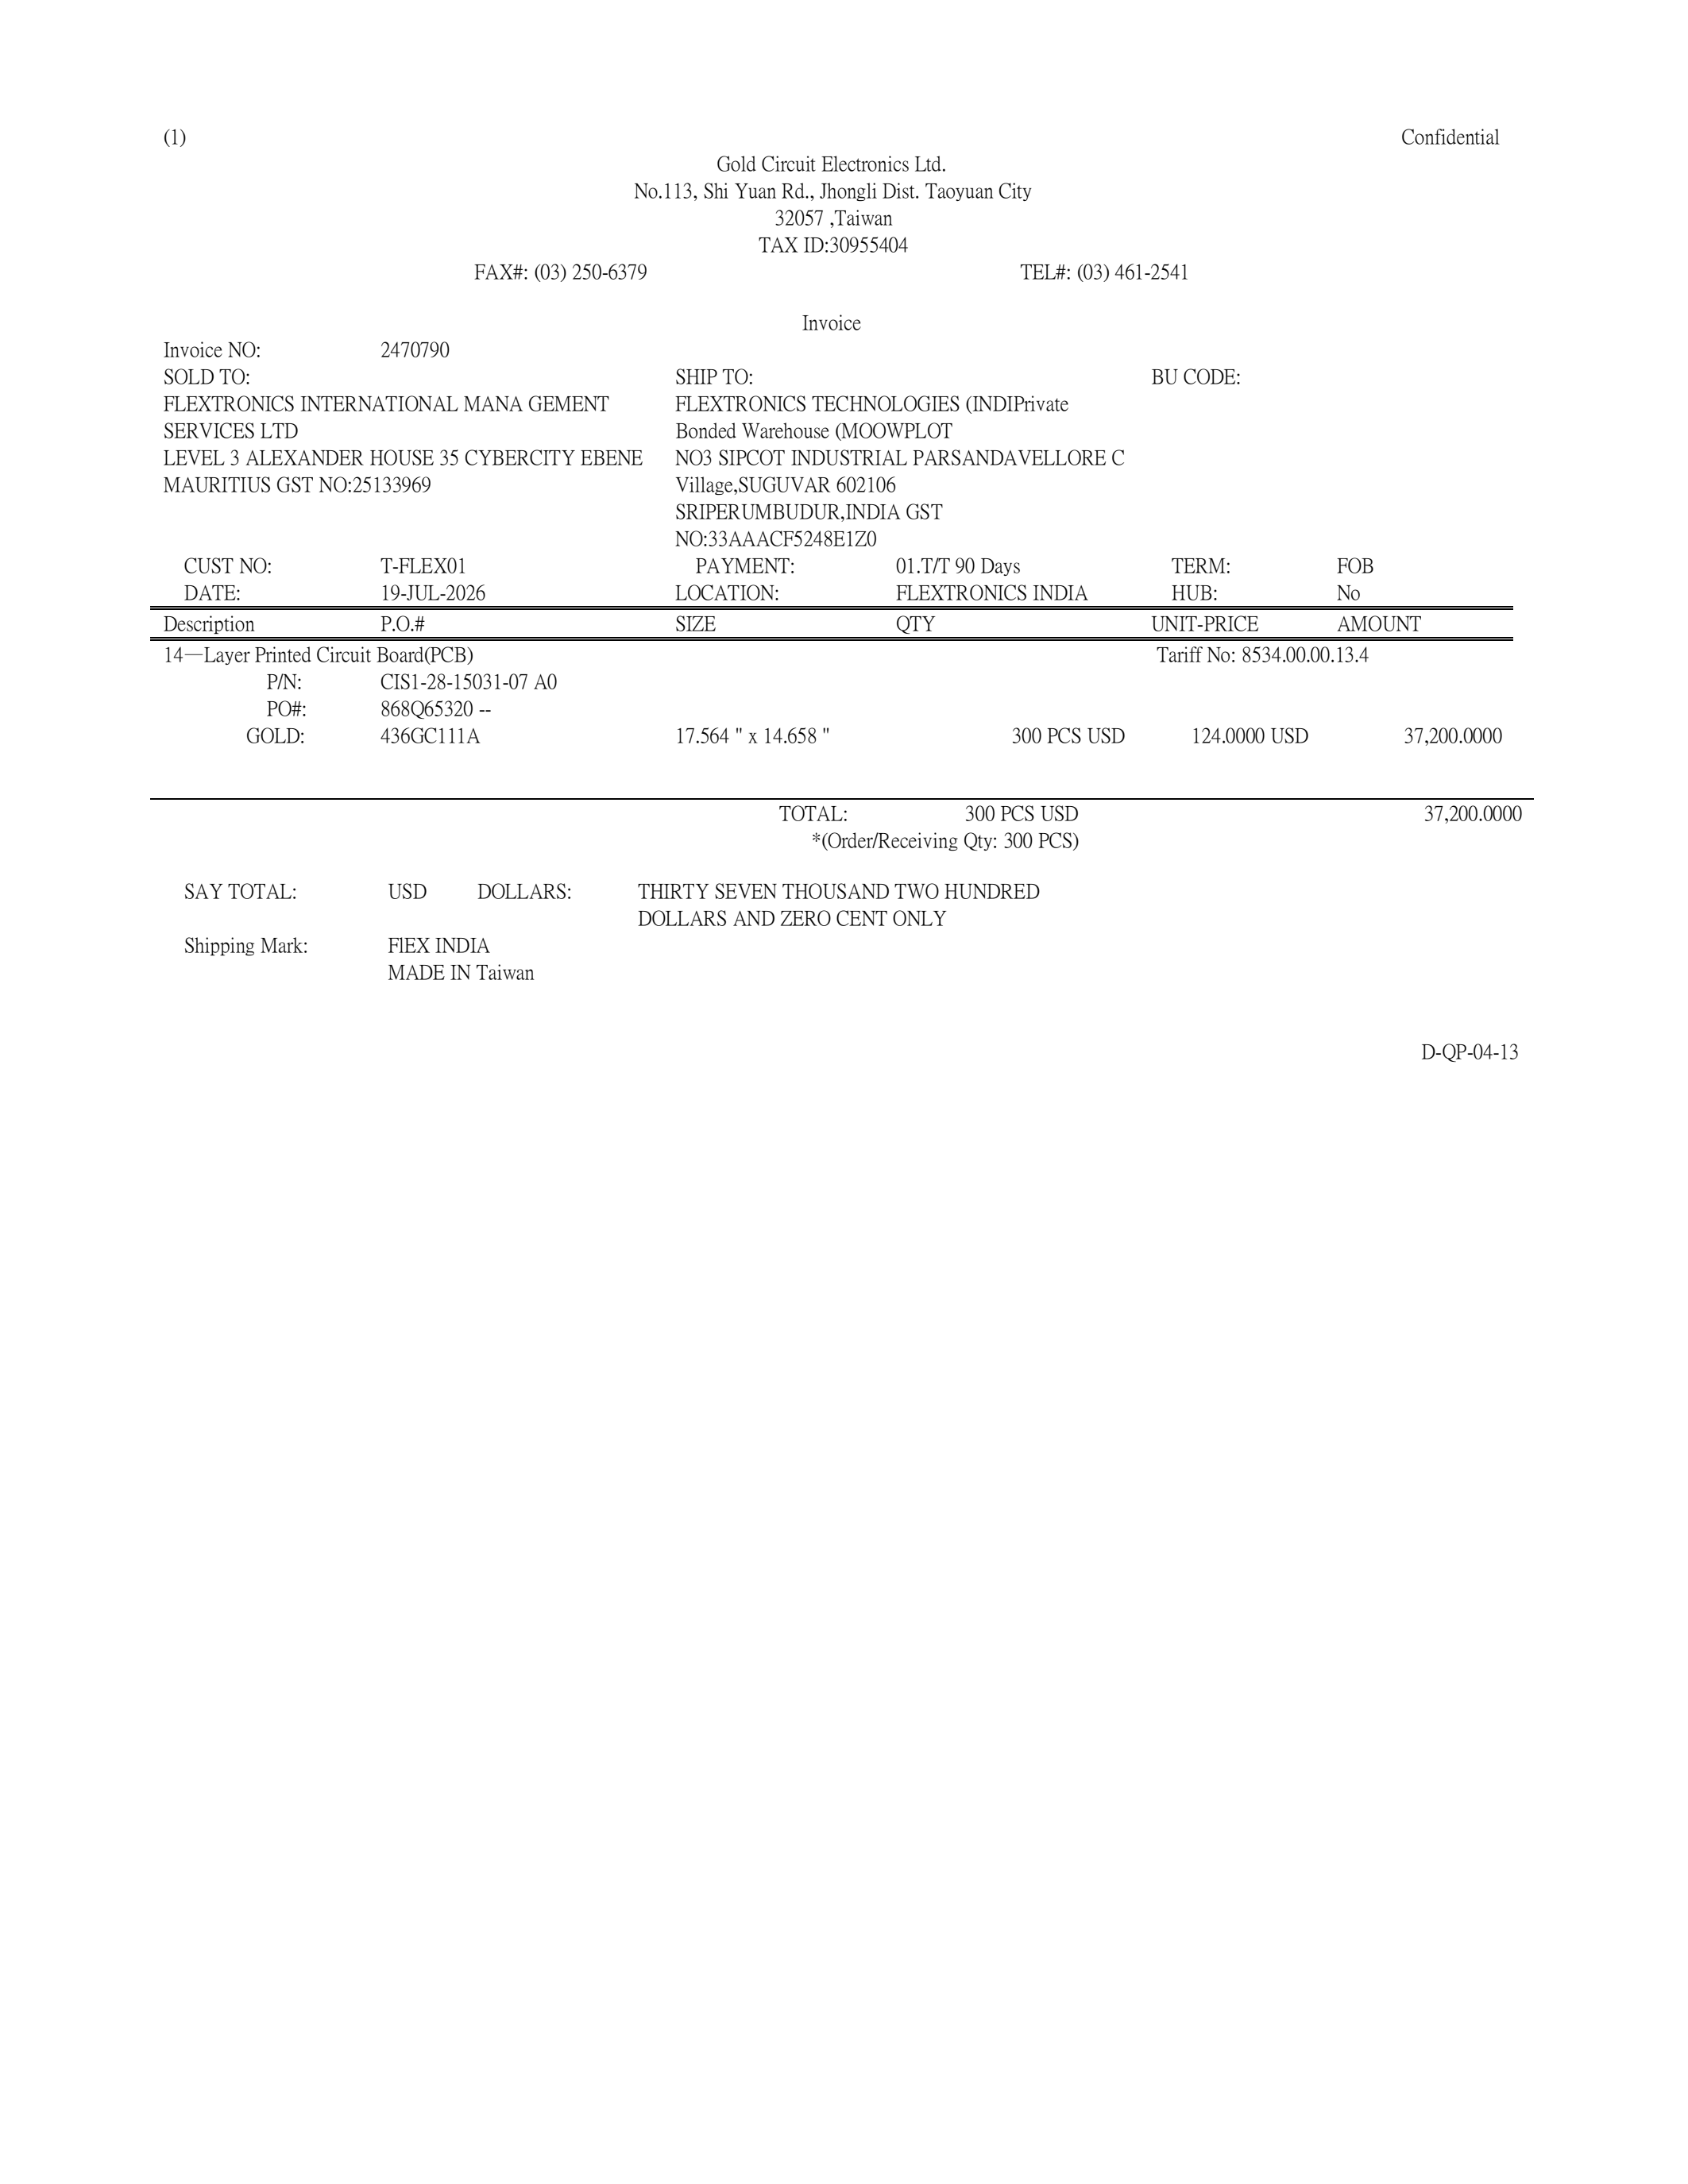

In [13]:
def render_pdf_to_data_urls(pdf_path: str, dpi: int = 250) -> list[str]:
    """Renders every page of `pdf_path` to a base64 PNG data URL -- same
    pypdfium2 rasterization call pdf_reader.py's OCR fallback uses."""
    scale = dpi / 72
    doc = pdfium.PdfDocument(pdf_path)
    urls = []
    for page in doc:
        bitmap = page.render(scale=scale)
        pil_image = bitmap.to_pil()
        buf = io.BytesIO()
        pil_image.save(buf, format="PNG")
        b64 = base64.b64encode(buf.getvalue()).decode("ascii")
        urls.append(f"data:image/png;base64,{b64}")
    return urls


image_data_urls = render_pdf_to_data_urls(PDF_PATH, dpi=IMAGE_DPI)
print(f"{len(image_data_urls)} page image(s) rendered")

# quick visual sanity check
from IPython.display import Image, display
for url in image_data_urls:
    display(Image(data=base64.b64decode(url.split(',', 1)[1]), width=500))

In [14]:
def _adapt_prompt_for_image(prompt: str, table_prompt: bool) -> str:
    """Swaps the TEXT-specific preamble of a production system prompt for
    an equivalent one suited to a rendered page IMAGE, leaving every
    substantive extraction rule below it untouched -- so this stays in
    sync with the real prompts in llm_extract.py instead of hand-copying
    a frozen duplicate that silently drifts out of date.

    Confirmed real problem this fixes: _HEADER_SYSTEM_PROMPT /
    _LINE_ITEMS_SYSTEM_PROMPT open by telling the model it receives
    "layout-preserved 2D spatial text" and that 'A "|" character marks a
    detected column boundary' -- both literally true for Path A's text
    input, but actively misleading for Path B: an image has no such
    character, and describing a text canvas to a model looking at a
    picture invites it to go hunting for something that will never
    appear. Without this swap, the two paths weren't actually using
    directly comparable instructions despite sharing the same prompt
    constant.

    Uses an exact substring replace (not a regex/heuristic) and asserts
    it actually matched, so a future edit to the real prompt's opening
    lines fails loudly here instead of silently leaving the text-specific
    wording in place for the image path.
    """
    if table_prompt:
        old = (
            'You receive the complete, layout-preserved 2D spatial text extracted from an invoice.\n'
            'The table rows and columns strictly maintain vertical alignment, linear gutters, and horizontal spacing without word collisions.\n'
            'A "│" character marks a detected column boundary -- text on either side of it is a separate table cell/column. Never merge text across a "│" into one field (e.g. never combine a description with the next column\'s code/qty/price just because they\'re on the same row).'
        )
        new = (
            "You receive one or more rendered page images of an invoice's table, in reading order.\n"
            "Read the table's rows and columns directly from the image's own visual grid, ruled lines, and spacing. "
            "Never merge text from two visually separate columns into one field just because they sit on the same row "
            "(e.g. never combine a description with the next column's code/qty/price)."
        )
    else:
        old = (
            'You receive the complete, layout-preserved 2D spatial text extracted from an invoice / export document.\n'
            'The text strictly preserves vertical alignment, multi-column separation, horizontal gutters, and word linearity without word collisions.\n'
            'A "│" character marks a detected column boundary -- text on either side of it belongs to separate fields/columns on that line. Never merge text across a "│" into one value or one sentence.'
        )
        new = (
            "You receive one or more rendered page images of an invoice / export document, in reading order.\n"
            "Read the visual layout directly from the image: side-by-side columns, multi-column tables, and row/column "
            "alignment are conveyed by the image's own spacing and ruled lines, not by any special character. Never merge "
            "text from two visually separate columns into one value just because they sit on the same row."
        )
    assert old in prompt, (
        "The text-specific preamble this adapter targets wasn't found verbatim -- "
        "llm_extract.py's prompt opening has changed; update `old`/`new` above to match."
    )
    return prompt.replace(old, new)


_HEADER_SYSTEM_PROMPT_IMAGE = _adapt_prompt_for_image(_HEADER_SYSTEM_PROMPT, table_prompt=False)
_LINE_ITEMS_SYSTEM_PROMPT_IMAGE = _adapt_prompt_for_image(_LINE_ITEMS_SYSTEM_PROMPT, table_prompt=True)
print("Adapted both prompts for image input (preamble swapped, all extraction rules unchanged).")

Adapted both prompts for image input (preamble swapped, all extraction rules unchanged).


In [15]:
def _image_content_blocks(urls: list[str]) -> list[dict]:
    return [{"type": "image_url", "image_url": {"url": u, "detail": "high"}} for u in urls]


async def extract_header_from_image(urls: list[str], model: str = MODEL):
    client = AsyncOpenAI(api_key=os.environ.get("OPENAI_API_KEY"))
    user_content = [{"type": "text", "text": "Extract the invoice header fields from this document image."}]
    user_content += _image_content_blocks(urls)

    request_kwargs = dict(
        model=model,
        messages=[
            {"role": "system", "content": _HEADER_SYSTEM_PROMPT_IMAGE},
            {"role": "user", "content": user_content},
        ],
    )
    if not _is_reasoning_model(model):
        request_kwargs["response_format"] = {"type": "json_object"}
    # No reasoning_effort override here, matching extract_invoice_header()
    # in llm_extract.py: tried "minimal"/"low" there on a real invoice
    # needing inference (an unlabeled buyer) and both regressed accuracy
    # (blank, then a wrong value) vs the unrestricted default -- so the
    # header pass stays at default effort on both paths.

    resp = await _call_header_model(client, request_kwargs)
    usage = _extract_usage(resp)
    return _extract_json(resp.choices[0].message.content), usage


async def extract_items_from_image(urls: list[str], model: str = MODEL):
    client = AsyncOpenAI(api_key=os.environ.get("OPENAI_API_KEY"))
    user_content = [{"type": "text", "text": "Extract every line item from this document image's table."}]
    user_content += _image_content_blocks(urls)

    request_kwargs = dict(
        model=model,
        messages=[
            {"role": "system", "content": _LINE_ITEMS_SYSTEM_PROMPT_IMAGE},
            {"role": "user", "content": user_content},
        ],
    )
    if not _is_reasoning_model(model):
        request_kwargs["response_format"] = {"type": "json_object"}
    else:
        # Matches extract_line_items() in llm_extract.py -- validated there
        # (real invoice, 29-30 item table) to hold row-completeness while
        # cutting cost substantially. Set here too so Path A and Path B's
        # items pass run at the same effort level; otherwise a cost/speed
        # difference between the two paths could come from this setting,
        # not the text-vs-image input modality being compared.
        request_kwargs["reasoning_effort"] = "minimal"
        request_kwargs["verbosity"] = "low"

    resp = await _call_line_items_model(client, request_kwargs)
    usage = _extract_usage(resp)
    data = _extract_json(resp.choices[0].message.content)
    if isinstance(data, list):
        return data, usage
    if isinstance(data, dict):
        for key in ("line_items", "items", "ITEM", "items_list"):
            if key in data and isinstance(data[key], list):
                return data[key], usage
    return [], usage

In [16]:
t0 = time.perf_counter()
image_header, header_usage = await extract_header_from_image(image_data_urls, model=MODEL)
image_items, items_usage = await extract_items_from_image(image_data_urls, model=MODEL)
image_elapsed = time.perf_counter() - t0

total_input = header_usage["input_tokens"] + items_usage["input_tokens"]
total_cached = header_usage["cached_tokens"] + items_usage["cached_tokens"]
total_output = header_usage["output_tokens"] + items_usage["output_tokens"]
image_usage = _calculate_cost(MODEL, total_input, total_cached, total_output)

print(f"[IMAGE PATH] {image_elapsed:.1f}s, {image_usage['total_tokens']} tokens, "
      f"${image_usage['cost_usd']:.5f} (INR {image_usage['cost_inr']:.4f})")
print(json.dumps(image_header, indent=2, ensure_ascii=False))
print(f"\n{len(image_items)} line item(s):")
print(json.dumps(image_items, indent=2, ensure_ascii=False))

[IMAGE PATH] 80.9s, 61878 tokens, $0.00605 (INR 0.5143)
{
  "invoice_number": "2464526 / 2470789 / 2470790",
  "invoice_date": "2026-07-17 / 2026-07-18 / 2026-07-19",
  "supplier_name": "Gold Circuit Electronics Ltd.",
  "supplier_address": "No.113, Shi Yuan Rd., Jhongli Dist. Taoyuan City 32057, Taiwan",
  "supplier_tax_id": "30955404",
  "buyer_name": "FLEXTRONICS INTERNATIONAL MANA GEMENT SERVICES LTD",
  "buyer_address": "LEVEL 3 ALEXANDER HOUSE 35 CYBERCITY EBENE MAURITIUS",
  "consignee_name": "FLEXTRONICS TECHNOLOGIES (INDIA PRIVATE)",
  "consignee_address": "Bonded Warehouse (MOOWPLOT NO3 SIPCOT INDUSTRIAL PARSANDA VELLORE C Village, SUGUVAR 602106 SRIPERUMBUDUR, INDIA",
  "currency": "USD",
  "invoice_total": "3720.0000 / 12400.0000 / 37200.0000",
  "net_realisable_amount": null,
  "tax_amount": null,
  "tax_rate": null,
  "payment_terms": "01.T/T 90 Days",
  "country_of_origin": "TAIWAN",
  "country_of_destination": "INDIA",
  "transit_country": null,
  "port_of_loading": nul

## Side-by-side comparison

In [17]:
import pandas as pd

header_fields = sorted(set(text_header) | set(image_header))
rows = [
    {
        "field": f,
        "TEXT path": text_header.get(f),
        "IMAGE path": image_header.get(f),
        "match": text_header.get(f) == image_header.get(f),
    }
    for f in header_fields
]
pd.set_option("display.max_colwidth", 80)
pd.DataFrame(rows)

,field,TEXT path,IMAGE path,match
0,ad_code,NaN,NaN,True
1,buyer_address,LEVEL 3 ALEXANDER HOUSE 35 CYBERCITY EBENE\nMAURITIUS,LEVEL 3 ALEXANDER HOUSE 35 CYBERCITY EBENE MAURITIUS,False
2,buyer_name,FLEXTRONICS INTERNATIONAL MANAGEMENT SERVICES LTD,FLEXTRONICS INTERNATIONAL MANA GEMENT SERVICES LTD,False
3,consignee_address,"NO3 SIPCOT INDUSTRIAL PARSANDAVELLORE\nVillage, SUGUVAR 602106\nSRIPERUMBUDU...","Bonded Warehouse (MOOWPLOT NO3 SIPCOT INDUSTRIAL PARSANDA VELLORE C Village,...",False
4,consignee_name,FLEXTRONICS TECHNOLOGIES (INDIA) Private Limited,FLEXTRONICS TECHNOLOGIES (INDIA PRIVATE),False
5,country_of_destination,INDIA,INDIA,True
6,country_of_origin,Taiwan,TAIWAN,False
7,currency,USD,USD,True
8,district_code,NaN,NaN,True
9,export_type_status,NaN,NaN,True


In [18]:
pd.DataFrame([
    {"path": "TEXT", "elapsed_s": round(text_elapsed, 1), "total_tokens": text_usage["total_tokens"],
     "cost_usd": text_usage["cost_usd"], "cost_inr": text_usage["cost_inr"]},
    {"path": "IMAGE", "elapsed_s": round(image_elapsed, 1), "total_tokens": image_usage["total_tokens"],
     "cost_usd": image_usage["cost_usd"], "cost_inr": image_usage["cost_inr"]},
])

,path,elapsed_s,total_tokens,cost_usd,cost_inr
0,TEXT,58.0,24544,0.003970,0.3374
1,IMAGE,80.9,61878,0.006051,0.5143


## Observations

_Fill in after running:_
- Did the image path recover `supplier_name` / `buyer_name` / addresses correctly where the text path's column-interleaving corrupted them?
- Any fields the TEXT path got right and the IMAGE path missed (e.g. small print, a value the model couldn't read at this DPI)?
- Which path was cheaper / faster, and by how much?
- If the image path wins on accuracy here, is it worth the extra image tokens on the invoices where the text path already works fine -- or is this best used as a targeted fallback specifically for files with confirmed source-level text corruption?